In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.datasets import load_iris
from scipy import stats

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [3]:
print("Размерность:", df.shape)
print("Кол-во признаков:", len(feature_names))
print("Кол-во классов:", len(np.unique(y)))

unique_values, counts = np.unique(y, return_counts=True)
print("\nКол-во объектов:")
for value, count in zip(unique_values, counts):
    print(f"  Класс {value} ({target_names[value]}): {count}")

stats_df = df.describe().T
modes = {}
for col in feature_names:
    mode_val = df[col].mode()[0] if not df[col].mode().empty else None
    modes[col] = mode_val
stats_df['mode'] = stats_df.index.map(modes)
print(stats_df.head())

Размерность: (150, 5)
Кол-во признаков: 4
Кол-во классов: 3

Кол-во объектов:
  Класс 0 (setosa): 50
  Класс 1 (versicolor): 50
  Класс 2 (virginica): 50
                   count      mean       std  min  25%   50%  75%  max  mode
sepal length (cm)  150.0  5.843333  0.828066  4.3  5.1  5.80  6.4  7.9   5.0
sepal width (cm)   150.0  3.057333  0.435866  2.0  2.8  3.00  3.3  4.4   3.0
petal length (cm)  150.0  3.758000  1.765298  1.0  1.6  4.35  5.1  6.9   1.4
petal width (cm)   150.0  1.199333  0.762238  0.1  0.3  1.30  1.8  2.5   0.2
target             150.0  1.000000  0.819232  0.0  0.0  1.00  2.0  2.0   NaN


In [4]:
if df.isnull().sum().sum() > 0:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"{median_val:.2f}")

    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
            df[col].fillna(mode_val, inplace=True)
            print({mode_val})
else:
    print("\nПропущенных значений не обнаружено")


Пропущенных значений не обнаружено


Кодирование категориальных признаков с помощью LabelEncoding

In [ ]:
df['target_name'] = df['target'].map({i: name for i, name in enumerate(target_names)})
if 'target_name' in df.columns:
    le = LabelEncoder()
    df['target_encoded'] = le.fit_transform(df['target_name'])
    print(dict(zip(le.classes_, range(len(le.classes_)))))--

{np.str_('setosa'): 0, np.str_('versicolor'): 1, np.str_('virginica'): 2}


Выявление выбросов

In [8]:
X_features = df[feature_names].copy()
y_target = df['target'].copy()

print(f"Размерность признаков: {X_features.shape}")
print(f"Размерность целевой переменной: {y_target.shape}")

Размерность признаков: (150, 4)
Размерность целевой переменной: (150,)


In [9]:
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_features)
X_std_df = pd.DataFrame(X_std, columns=[f"{col}_std" for col in feature_names])

print("Среднее значение:", X_std.mean(axis=0).round(6))
print("Стандартное отклонение:", X_std.std(axis=0).round(6))

Среднее значение: [-0. -0. -0. -0.]
Стандартное отклонение: [1. 1. 1. 1.]


In [11]:
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X_features)
X_mm_df = pd.DataFrame(X_mm, columns=[f"{col}_mm" for col in feature_names])

print("Минимум после нормализации:", X_mm.min(axis=0).round(6))
print("Максимум после нормализации:", X_mm.max(axis=0).round(6))

Минимум после нормализации: [0. 0. 0. 0.]
Максимум после нормализации: [1. 1. 1. 1.]


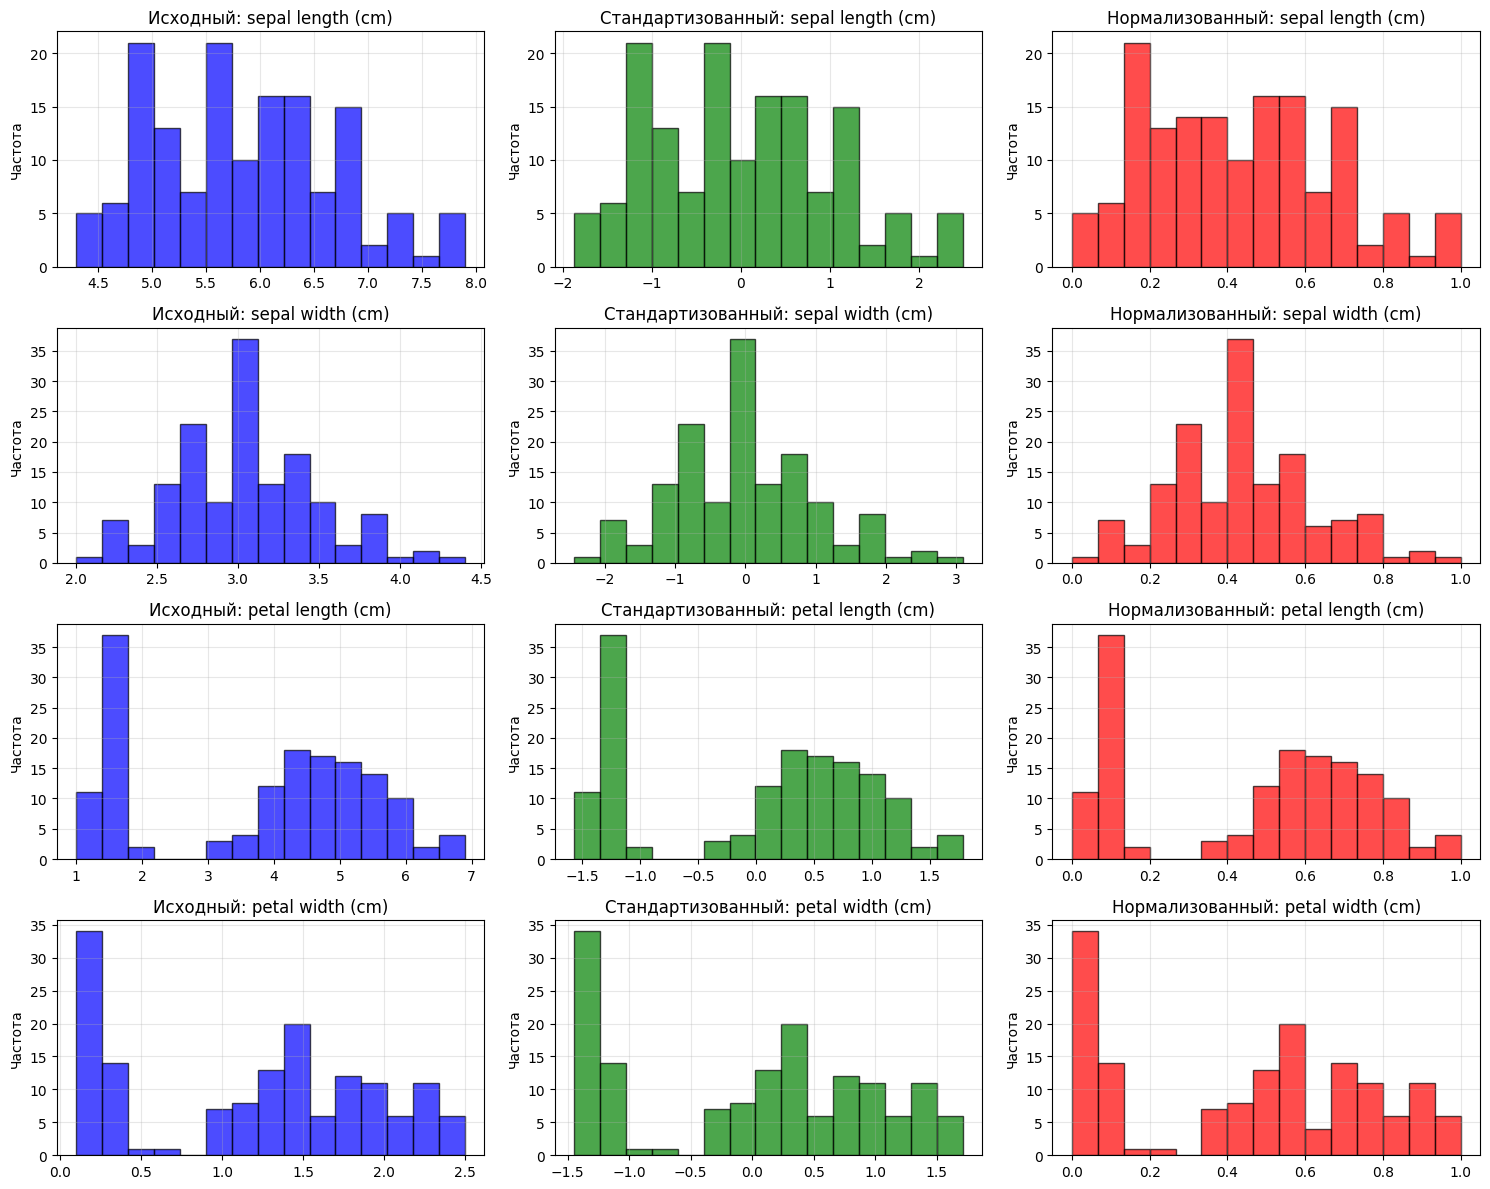

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))

colors = ['blue', 'green', 'red']

for idx, col in enumerate(feature_names):
    axes[idx, 0].hist(X_features[col], bins=15, color=colors[0], edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'Исходный: {col}')
    axes[idx, 0].set_ylabel('Частота')
    axes[idx, 0].grid(True, alpha=0.3)

    axes[idx, 1].hist(X_std[:, idx], bins=15, color=colors[1], edgecolor='black', alpha=0.7)
    axes[idx, 1].set_title(f'Стандартизованный: {col}')
    axes[idx, 1].set_ylabel('Частота')
    axes[idx, 1].grid(True, alpha=0.3)
    
    axes[idx, 2].hist(X_mm[:, idx], bins=15, color=colors[2], edgecolor='black', alpha=0.7)
    axes[idx, 2].set_title(f'Нормализованный: {col}')
    axes[idx, 2].set_ylabel('Частота')
    axes[idx, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Корреляция Пирсона

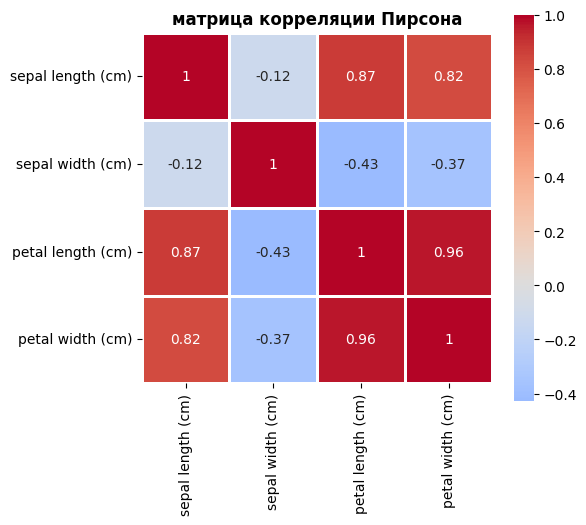

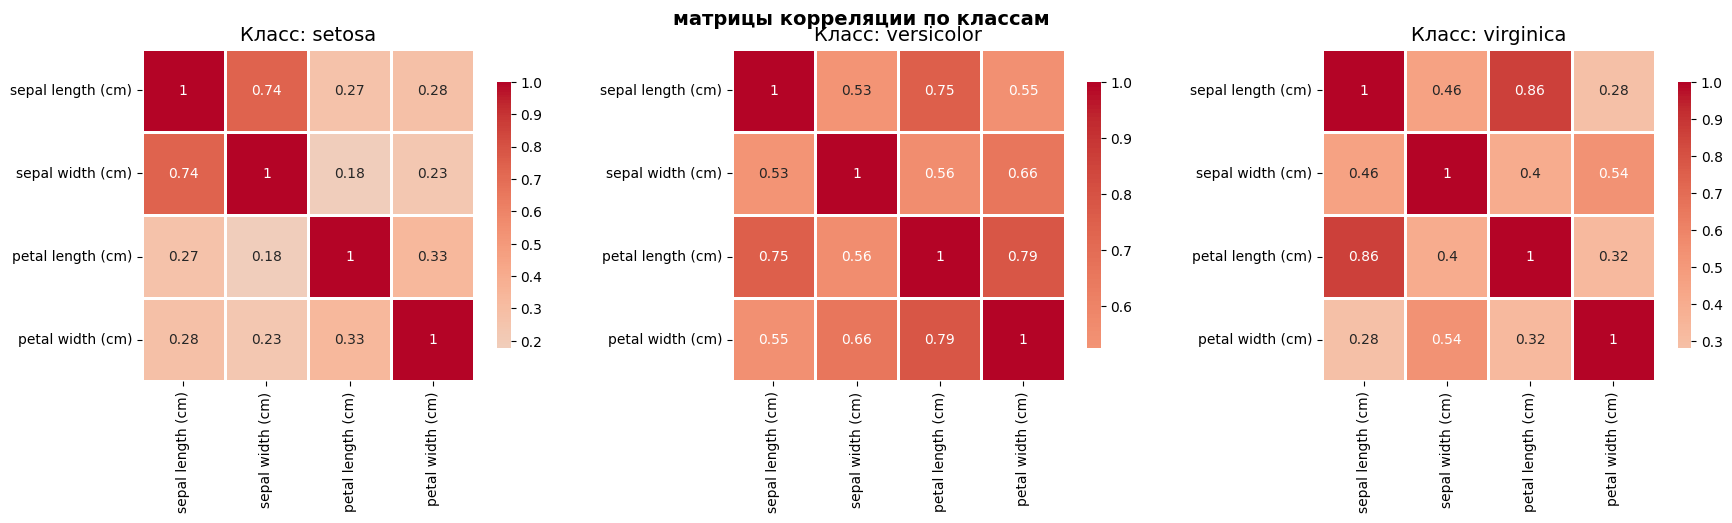

In [13]:
corr_matrix = X_features.corr()

plt.figure(figsize=(6, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('матрица корреляции Пирсона', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('матрицы корреляции по классам', fontsize=14, fontweight='bold')

for i, class_name in enumerate(target_names):
    class_data = X_features[df['target'] == i]
    class_corr = class_data.corr()
    sns.heatmap(class_corr, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                ax=axes[i])
    axes[i].set_title(f'Класс: {class_name}', fontsize=14)

plt.tight_layout()
plt.show()

Самая сильная корреляция в наборе данных между petal length и petal width — коэффициент 0.96. Следовательно это почти линейная зависимость: чем длиннее лепесток, тем он шире. 
Связь чашелистиков и лепестков: sepal length сильно положительно коррелирует с размерами лепестков. Значит цветки с длинными чашелистиками, имеют и большие лепестки.

Доля дисперсии каждой компоненты:
  Компонента 1: 0.7296
  Компонента 2: 0.2285
Суммарная доля дисперсии: 0.9581


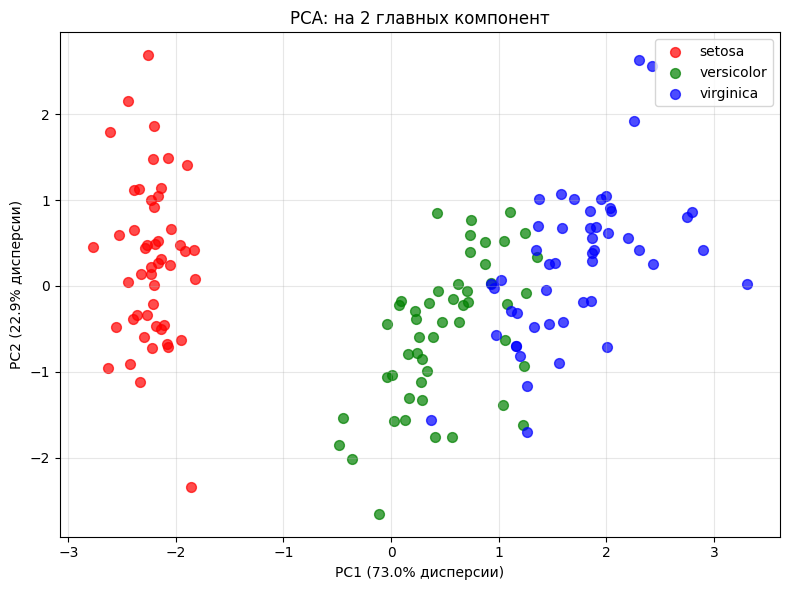

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

expl_var = pca.explained_variance_ratio_
print("Доля дисперсии каждой компоненты:")
for i, var in enumerate(expl_var, 1):
    print(f"  Компонента {i}: {var:.4f}")

sum_expl_var = expl_var.sum()
print(f"Суммарная доля дисперсии: {sum_expl_var:.4f}")

fig1, ax1 = plt.subplots(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for i, class_name in enumerate(target_names):
    mask = (y_target == i)
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], color=colors[i], alpha=0.7, label=class_name, s=50)

ax1.set_xlabel(f'PC1 ({expl_var[0]*100:.1f}% дисперсии)')
ax1.set_ylabel(f'PC2 ({expl_var[1]*100:.1f}% дисперсии)')
ax1.set_title('PCA: на 2 главных компонент')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Две главные компоненты (PC1 и PC2) вместе объясняют 95.81% общей дисперсии данных. Значит переход от 4 исходных признаков к 2 главным компонентам прошел почти без потери информации. Сохранена почти вся структура данных.  
PC1 объясняет 73% дисперсии, она отвечает за основное разделение данных (отделение Setosa от остальных).  
PC2 объясняет 22.9% дисперсии, она разделяет Versicolor и Virginica.  
Класс Setosa отделен, признаки, характерные для ириса сетоса, сильно отличаются от признаков других видов.

c:\Users\Стелла\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\Стелла\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


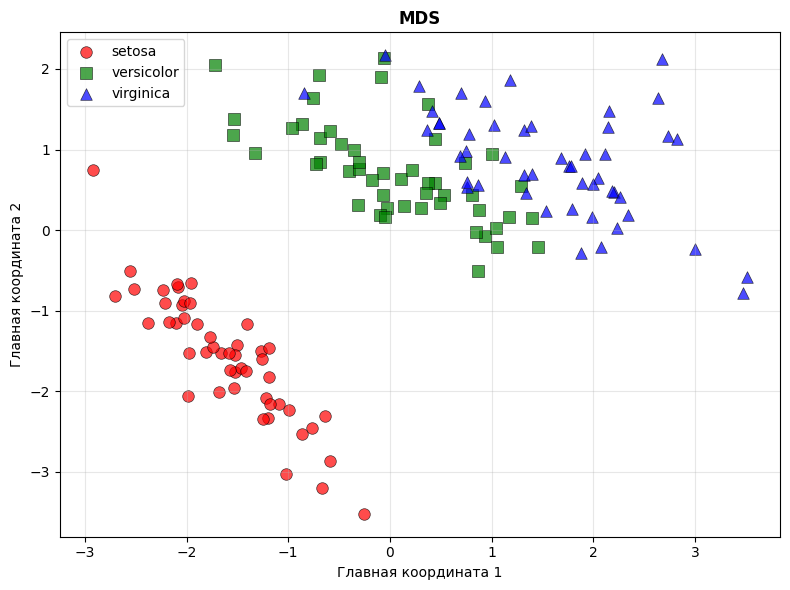

In [16]:
mds = MDS(n_components=2, random_state=42, normalized_stress='auto')
X_mds = mds.fit_transform(X_std)

plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
markers = ['o', 's', '^']
for target_class in np.unique(y_target):
    class_name = target_names[target_class]
    mask = (y_target == target_class)
    plt.scatter(X_mds[mask, 0], X_mds[mask, 1], color=colors[target_class], marker=markers[target_class],
                alpha=0.7, s=70, edgecolor='black', linewidth=0.5, label=f'{class_name}')

plt.xlabel('Главная координата 1')
plt.ylabel('Главная координата 2')
plt.title('MDS', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_std, y_target, test_size=0.2, random_state=42, stratify=y_target
)

log_reg = LogisticRegression(random_state=42, max_iter=200)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



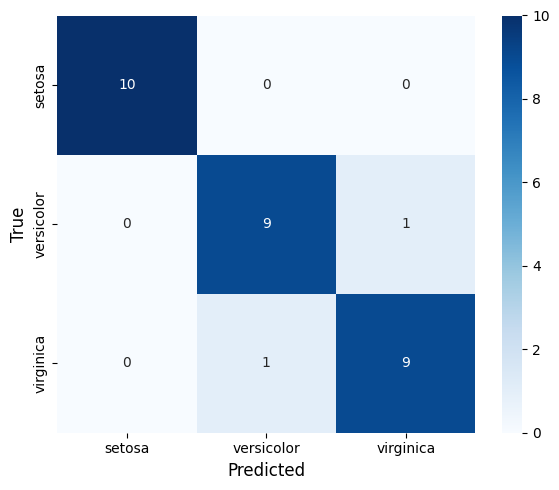

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.tight_layout()
plt.show()

Setosa показывает идеальную классификация, а versicolor и virginica - 90% точность (так как эти виды похожи). Общая точность: 93.33%.